## Read and format data

In [134]:
from datetime import datetime, date 

In [135]:
from pathlib import Path

def collect_lines_from_txt(txt_file: str) -> list:
    results = list()
    print(f"Processing file: {txt_file}")
    with Path(txt_file).open("r", encoding="utf-8") as handle:
        for line in handle:
            line = line.rstrip("\n")
            if 'cycle' in line:
                l = next(handle).rstrip("\n")
                l = l.replace("Period start date: ", "")
                results.append(datetime.strptime(l, "%Y-%m-%d %H:%M:%S.%f").date())
    return results

In [136]:
cycles = collect_lines_from_txt("C:\\Users\\kikka\\Documents\\Projects\\poc_cycle\\data\\res.txt")

Processing file: C:\Users\kikka\Documents\Projects\poc_cycle\data\res.txt


In [137]:
cycles[0]

datetime.date(2016, 5, 14)

In [138]:
len(cycles)

119

In [139]:
# Add recent points
more_dates = list([date(2025, 9, 15), date(2025, 10, 13), date(2025, 11, 8), date(2025, 12, 5), date(2026, 1, 5), date(2026, 1, 31), date(2026, 2, 25), date(2026, 3, 23), date(2026, 4, 18), date(2026, 5, 18), date(2026, 6, 13)])
cycles.extend(more_dates)

In [140]:
cycles[-1]

datetime.date(2026, 6, 13)

In [141]:
import pandas as pd 
cycles_df = pd.DataFrame(cycles, columns=['date'])
cycles_df.to_csv("C:\\Users\\kikka\\Documents\\Projects\\poc_cycle\\data\\cycles.csv", index=False)

# EDA

In [142]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.pyplot

In [143]:
cycles_df.date = pd.to_datetime(cycles_df.date)

In [144]:
cycles_df 

,date
0,2016-05-14
1,2016-06-10
2,2016-07-06
3,2016-07-28
4,2016-08-22
...,...
125,2026-02-25
126,2026-03-23
127,2026-04-18
128,2026-05-18


In [146]:
cycles_df["cycle_id"] = cycles_df.index

In [147]:
cycles_df.set_index("date", inplace=True)

In [149]:
cycles_df['year'] = cycles_df.index.year
cycles_df['month'] = cycles_df.index.month
cycles_df['day'] = cycles_df.index.day

In [150]:
cycles_df

,cycle_id,year,month,day
date,,,,
2016-05-14,0,2016,5,14
2016-06-10,1,2016,6,10
2016-07-06,2,2016,7,6
2016-07-28,3,2016,7,28
2016-08-22,4,2016,8,22
...,...,...,...,...
2026-02-25,125,2026,2,25
2026-03-23,126,2026,3,23
2026-04-18,127,2026,4,18


In [151]:
cycles_df['cycle_duration'] = cycles_df.index.to_series().diff().shift(-1).dt.days

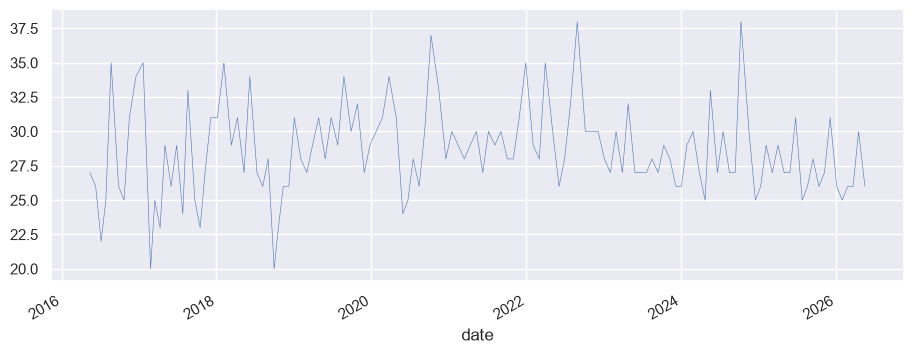

In [152]:
# Use seaborn style defaults and set the default figure size
sns.set(rc={'figure.figsize':(11, 4)})
cycles_df['cycle_duration'].plot(linewidth=0.4);

In [153]:
cycles_df.to_csv("C:\\Users\\kikka\\Documents\\Projects\\poc_cycle\\data\\cycles_with_durations.csv", index=False)

In [154]:
cycles_df

,cycle_id,year,month,day,cycle_duration
date,,,,,
2016-05-14,0,2016,5,14,27.0
2016-06-10,1,2016,6,10,26.0
2016-07-06,2,2016,7,6,22.0
2016-07-28,3,2016,7,28,25.0
2016-08-22,4,2016,8,22,35.0
...,...,...,...,...,...
2026-02-25,125,2026,2,25,26.0
2026-03-23,126,2026,3,23,26.0
2026-04-18,127,2026,4,18,30.0
